这是一个非常典型的二分类（Binary Classification）机器学习项目。根据你提供的图片 `image_6e4928.png` 里的数据集字段（如 `no_show`, `branch`, `booking_month`, `price`, `country` 等），我为你规划了一个清晰、结构化的项目实施框架。

你可以直接按照这个框架来组织你的 Jupyter Notebook 或项目报告：

---

## 🏨 酒店客户 No-Show 预测项目框架

### 1. 业务理解与目标定义 (Business Understanding)

* **核心目标：** 预测客户是否会 No-Show（目标变量：`no_show`），从而帮助酒店集团制定针对性的政策（如：超卖政策、押金政策、取消预订提醒等），以降低因客户未入住带来的经济损失。
* **评价指标选择：**
* 不能只看准确率（Accuracy），因为 No-Show 通常是少数派，存在样本不均衡问题。
* **重点关注：** **F1-Score** 或 **ROC-AUC**。同时要权衡 **Precision（精准率）** 和 **Recall（召回率）**。
* *业务思考：* 如果把会来的客户误判为 No-Show（低 Precision），可能导致超卖引起客户投诉；如果漏掉了真正会 No-Show 的客户（低 Recall），则无法挽回经济损失。



### 2. 数据探索性分析 (EDA)

从图片 `image_6e4928.png` 中可以看到，数据集包含 119,391 条数据，共 15 列。你需要重点探索以下内容：

* **目标变量分布：** 统计 `no_show` 中 `0.0` 和 `1.0` 的比例，确认是否存在类别不均衡。
* **缺失值查看：** 图片中可以看到 `price` 列含有 `NaN`，需要统计各列的缺失值比例。
* **特征关联性分析：**
* **时间维度：** 预订月份（`booking_month`）与入住月份（`arrival_month`）之间的差值（前置时间 Lead Time）往往对 No-Show 有重大影响。
* **渠道与价格：** 不同渠道（`platform`：如 Website, Agent）、房间类型（`room`）以及价格（`price`）与 No-Show 的关系。
* **地域与新老客户：** 客户国家（`country`）和是否第一次入住（`first_time`）的分布。



### 3. 数据预处理与特征工程 (Data Preprocessing & Feature Engineering)

这是模型成败的关键，针对 `image_6e4928.png` 展示的数据，你需要做：

* **数据清洗：**
* 处理 `price` 的货币符号（如将 `SGD$ 492.98`, `USD$ 665.37` 统一转换为同一种货币的数值，并填补 `NaN` 缺失值）。
* 处理其他微小缺失值（如 `num_children` 的单个缺失值）。


* **特征衍生（衍生出更有用的特征）：**
* 计算 `Lead Time`（预订月份到入住月份的跨度）。
* 计算总人数：`num_adults` + `num_children`。


* **特征编码（Encoding）：**
* 对分类变量（`branch`, `platform`, `room`, `country`, `first_time` 等）进行独热编码（One-Hot Encoding）或目标编码（Target Encoding）。


* **数据划分：** 按 80/20 或 70/30 的比例将数据集划分为**训练集**和**测试集**。如有必要，使用 `SMOTE` 等方法处理类别不均衡。

### 4. 模型训练与评估 (Model Training - 至少3个模型)

为了符合项目要求，建议选择以下三种在非结构化表格数据中表现优异且原理不同的经典模型：

* **模型 A：逻辑回归 (Logistic Regression)**
* *理由：* 作为 Baseline（基线模型），计算速度快，可解释性强。


* **模型 B：随机森林 (Random Forest)**
* *理由：* 集成学习算法，能很好地处理非线性关系，不易过拟合，对缺失值不敏感。


* **模型 C：LightGBM 或 XGBoost**
* *理由：* 基于梯度提升树（GBDT）的现代大杀器，处理大规模表格数据性能极佳，速度快且准确率高。



### 5. 模型对比与综合评估 (Overall Evaluation)

这部分是回答你要求的“如何对比并解释哪个模型更合适”：

* **量化对比表：** 创建一个表格，在测试集上对比三个模型的以下指标：
| 模型 | Accuracy | Precision | Recall | F1-Score | ROC-AUC | 训练耗时 |
| --- | --- | --- | --- | --- | --- | --- |
| 逻辑回归 |  |  |  |  |  |  |
| 随机森林 |  |  |  |  |  |  |
| LightGBM |  |  |  |  |  |  |


* **可视化对比：** 绘制 **ROC 曲线 (Receiver Operating Characteristic Curve)** 和 **PR 曲线 (Precision-Recall Curve)**，观察曲线下面积。
* **业务决策与模型选择解释：**
* 不能只看谁的分数高。如果 LightGBM 和随机森林分数差不多，但 LightGBM 预测速度快、占用内存小，那它在实际业务工程落地中更合适。
* 解释为什么选中的模型更适合该任务（例如：“LightGBM 拥有最高的 F1-Score，能够在避免过度超卖带来投诉的同时，最大化帮酒店挽回 No-Show 损失”）。



### 6. 业务建议与政策制定 (Business Insights)

* **特征重要性分析 (Feature Importance)：** 输出选中模型的前 5 个核心特征（例如发现：通过 Agent 预订、且 Lead Time 超过 3 个月的客户最容易 No-Show）。
* **基于结论的政策建议：**
* 针对高风险 No-Show 预订，推行“非不退款”预付价或收取一定比例押金。
* 在入住前 3 天通过短信/邮件自动触发入住确认提醒。
* 根据模型的预测概率动态调整酒店的超卖比例（Overbooking Limit）。



---

你可以根据这个框架开始在 Jupyter Notebook（即你图中的 `MiniProject_2.ipynb`）中编写代码了。祝你项目顺利！有什么具体步骤（比如怎么洗货币数据）需要帮忙的，随时问我。

In [3]:
import pandas as pd
import numpy as ny


df = pd.read_csv(r"C:\Users\yangguang\Desktop\AIAP course\Mini Project 2\mini_project_2_data.csv")

print(df.head())
print(df.info())


   booking_id  no_show   branch booking_month arrival_month  arrival_day  \
0       94113      0.0   Changi      November          June         25.0   
1       86543      0.0  Orchard        August      November         28.0   
2       75928      0.0   Changi         March      February          7.0   
3       66947      1.0  Orchard     September       October          1.0   
4      106390      0.0  Orchard         March          June         20.0   

  checkout_month  checkout_day    country first_time    room         price  \
0           June          27.0  Singapore        Yes  Single   SGD$ 492.98   
1       November          29.0  Indonesia        Yes    King  SGD$ 1351.22   
2       February          11.0      India        Yes  Single           NaN   
3        October           3.0      China        Yes  Single   SGD$ 666.04   
4           June          24.0  Australia        Yes   Queen   USD$ 665.37   

  platform num_adults  num_children  
0  Website          1           0.0 

=== 1. 数据基本信息 ===
<class 'pandas.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119391 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  str    
 3   booking_month   119390 non-null  str    
 4   arrival_month   119390 non-null  str    
 5   arrival_day     119390 non-null  float64
 6   checkout_month  119390 non-null  str    
 7   checkout_day    119390 non-null  float64
 8   country         119390 non-null  str    
 9   first_time      119390 non-null  str    
 10  room            97778 non-null   str    
 11  price           94509 non-null   str    
 12  platform        119390 non-null  str    
 13  num_adults      119390 non-null  str    
 14  num_children    119390 non-null  float64
dtypes: float64(4), int64(1), str(10)
memory usage: 13.7 MB
None

=== 2. 缺失值统计 ===
                缺

C:\Users\yangguang\AppData\Local\Temp\ipykernel_59108\3477734758.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
C:\Users\yangguang\AppData\Local\Temp\ipykernel_59108\3477734758.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='no_show', data=df, palette='Set2')


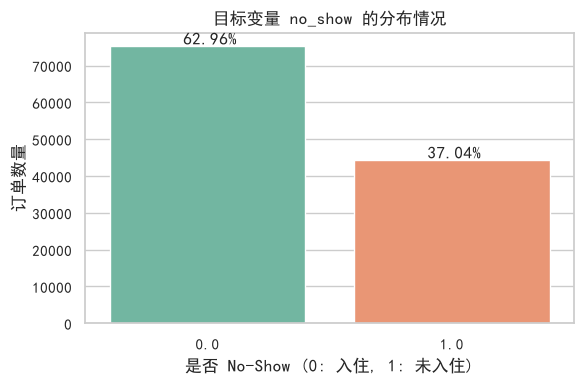

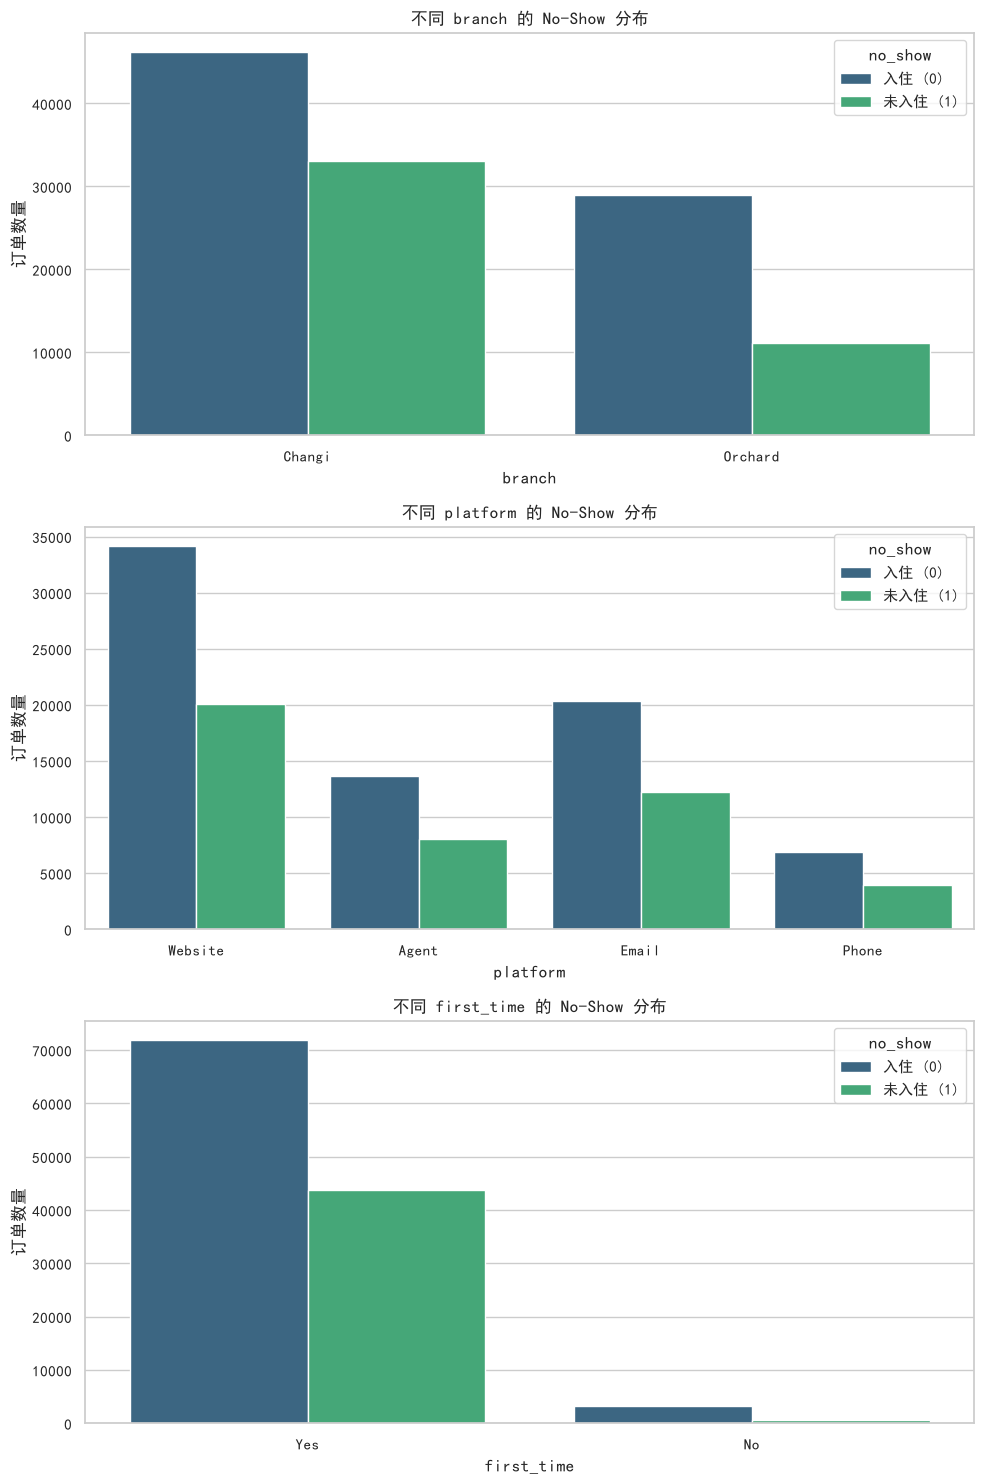

C:\Users\yangguang\AppData\Local\Temp\ipykernel_59108\3477734758.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='no_show', y='num_adults', data=df, palette='pastel')
C:\Users\yangguang\AppData\Local\Temp\ipykernel_59108\3477734758.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='no_show', y='num_children', data=df, palette='pastel')


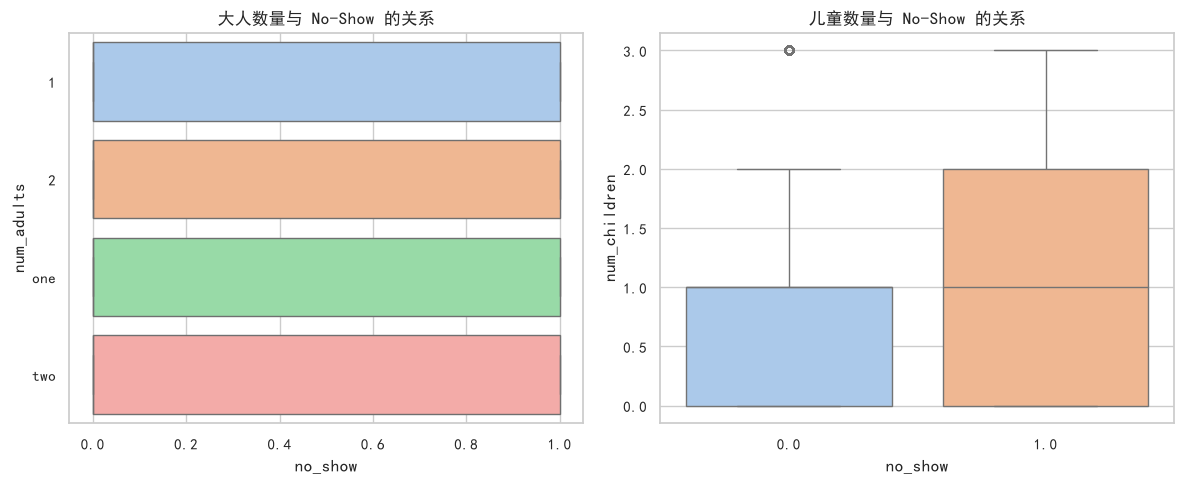

C:\Users\yangguang\AppData\Local\Temp\ipykernel_59108\3477734758.py:104: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_plot['arrival_month'] = pd.Categorical(df_plot['arrival_month'], categories=available_months, ordered=True)


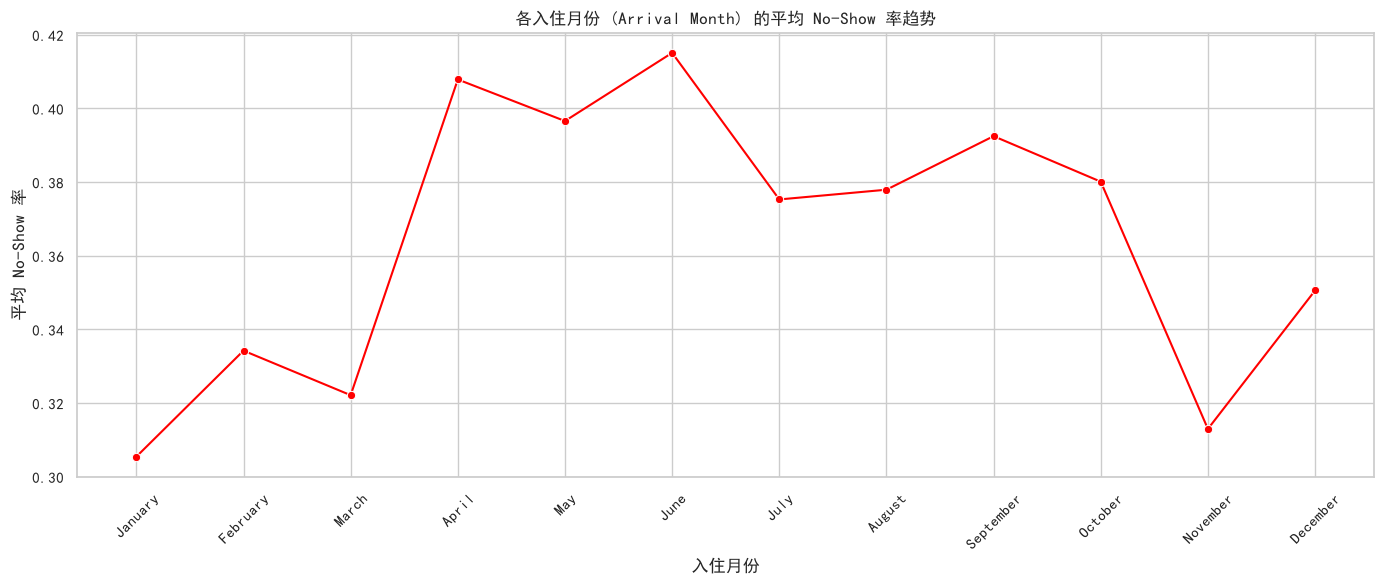

In [5]:
# =====================================================================
# 2. 探索性数据分析 (EDA)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 设置画图风格与中文字体（防止乱码，如果不需要中文可以去掉 font.sans-serif）
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------------------
# 2.1 基础信息与缺失值检查
# ---------------------------------------------------------------------
print("=== 1. 数据基本信息 ===")
print(df.info())

print("\n=== 2. 缺失值统计 ===")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'缺失值个数': missing_values, '缺失值比例 (%)': missing_percentage})
print(missing_df[missing_df['缺失值个数'] > 0])

print("\n=== 3. 数值型特征统计描述 ===")
print(df.describe())

print("\n=== 4. 类别型特征唯一值统计 ===")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} 个唯一值")

# ---------------------------------------------------------------------
# 2.2 目标变量分布 (Target Variable Distribution)
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='no_show', data=df, palette='Set2')
plt.title('目标变量 no_show 的分布情况')
plt.xlabel('是否 No-Show (0: 入住, 1: 未入住)')
plt.ylabel('订单数量')

# 在条形图上添加百分比标签
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 500
    ax.annotate(percentage, (x, y))

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2.3 核心类别特征与 No-Show 的关系分析
# ---------------------------------------------------------------------
# 我们挑选几个关键特征：分支机构、预订平台、是否第一次入住
features_to_plot = ['branch', 'platform', 'first_time']

fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(10, 5 * len(features_to_plot)))

for i, col in enumerate(features_to_plot):
    # 计算每个类别下的 No-Show 率
    sns.countplot(x=col, hue='no_show', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'不同 {col} 的 No-Show 分布')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('订单数量')
    axes[i].legend(title='no_show', labels=['入住 (0)', '未入住 (1)'])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2.4 客人组成（大人/儿童）与 No-Show 的关系
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='no_show', y='num_adults', data=df, palette='pastel')
plt.title('大人数量与 No-Show 的关系')

plt.subplot(1, 2, 2)
sns.boxplot(x='no_show', y='num_children', data=df, palette='pastel')
plt.title('儿童数量与 No-Show 的关系')

plt.tight_layout()
plt.show()



# ---------------------------------------------------------------------
# 2.5 预订月份与入住月份的趋势分析（已修正版）
# ---------------------------------------------------------------------
# 查看哪些月份是 No-Show 的高发期
plt.figure(figsize=(14, 6))

# 1. 定义标准的月份顺序
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 2. 过滤掉数据中可能不存在的月份
available_months = [m for m in month_order if m in df['arrival_month'].unique()]

# 3. 临时将 arrival_month 转换为带有顺序的 Categorical 类型，以便 Seaborn 自动排序
df_plot = df.copy()
df_plot['arrival_month'] = pd.Categorical(df_plot['arrival_month'], categories=available_months, ordered=True)

# 4. 绘图（去掉了不支持的 order 参数，并将 ci=None 改为新版推荐的 errorbar=None）
sns.lineplot(
    x='arrival_month', 
    y='no_show', 
    data=df_plot, 
    errorbar=None, 
    marker='o', 
    color='red'
)

plt.title('各入住月份 (Arrival Month) 的平均 No-Show 率趋势')
plt.xlabel('入住月份')
plt.ylabel('平均 No-Show 率')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# =====================================================================
# 3. 数据预处理与特征工程
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 复制一份数据，避免修改原始 df
df_clean = df.copy()

# ---------------------------------------------------------------------
# 3.1 目标变量清洗
# ---------------------------------------------------------------------
# 目标变量 no_show 绝不能有缺失值，直接删除缺失的那 1 行
df_clean = df_clean.dropna(subset=['no_show'])
df_clean['no_show'] = df_clean['no_show'].astype(int)

# ---------------------------------------------------------------------
# 3.2 文本型数字清洗 (num_adults)
# ---------------------------------------------------------------------
# 将 'one', 'two' 映射为数字，并转换为数值型
adults_mapping = {'1': 1, '2': 2, 'one': 1, 'two': 2}
df_clean['num_adults'] = df_clean['num_adults'].map(adults_mapping)
# 如果有未识别的残余缺失值，用众数填充
df_clean['num_adults'] = df_clean['num_adults'].fillna(df_clean['num_adults'].mode()[0]).astype(int)

# 顺便确保儿童数量也是整数，缺失值用 0 填充
df_clean['num_children'] = df_clean['num_children'].fillna(0).astype(int)

# ---------------------------------------------------------------------
# 3.3 价格清洗与统一汇率 (price)
# ---------------------------------------------------------------------
def clean_and_convert_price(price_str):
    if pd.isna(price_str) or str(price_str).strip() == 'NaN':
        return np.nan
    price_str = str(price_str).upper()
    
    # 提取数字部分
    try:
        # 移除货币符号和空格，只保留数字和小数点
        num_val = float(''.join(c for c in price_str if c.isdigit() or c == '.'))
    except ValueError:
        return np.nan
        
    # 统一汇率（以新加坡元 SGD 为基准，假设 1 USD = 1.35 SGD）
    if 'USD' in price_str:
        return num_val * 1.35
    elif 'SGD' in price_str:
        return num_val
    else:
        return num_val  # 如果没有货币符号，默认当作 SGD

# 转换价格列
df_clean['price_sgd'] = df_clean['price'].apply(clean_and_convert_price)

# 价格缺失值填充：按照不同的 room 类型和 branch 分组，用中位数填充
df_clean['price_sgd'] = df_clean.groupby(['branch', 'room'])['price_sgd'].transform(lambda x: x.fillna(x.median()))
# 如果还有少量漏网之鱼（比如某些房间和分支组合全缺失），用全局中位数填充
df_clean['price_sgd'] = df_clean['price_sgd'].fillna(df_clean['price_sgd'].median())

# ---------------------------------------------------------------------
# 3.4 缺失值处理 (room)
# ---------------------------------------------------------------------
# room 缺失值较多，直接将其归为独立的一类 'Unknown'
df_clean['room'] = df_clean['room'].fillna('Unknown')

# ---------------------------------------------------------------------
# 3.5 特征衍生 (Feature Engineering)
# ---------------------------------------------------------------------
# 1. 衍生特征：总出行人数
df_clean['total_guests'] = df_clean['num_adults'] + df_clean['num_children']

# 2. 衍生特征：计算预订到入住的月份差 (Lead Time Months)
month_to_num = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}
b_month_num = df_clean['booking_month'].map(month_to_num)
a_month_num = df_clean['arrival_month'].map(month_to_num)

# 计算差值（考虑跨年的情况）
df_clean['lead_time_months'] = (a_month_num - b_month_num) % 12

# ---------------------------------------------------------------------
# 3.6 特征选择与哑变量编码 (Encoding)
# ---------------------------------------------------------------------
# 剔除无用的 ID 列和已经被替代的原始列
cols_to_drop = ['booking_id', 'booking_month', 'price', 'checkout_month', 'checkout_day']
df_model = df_clean.drop(columns=cols_to_drop)

# 识别剩余的类别型特征进行 One-Hot 编码
categorical_cols = ['branch', 'arrival_month', 'country', 'first_time', 'room', 'platform']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# ---------------------------------------------------------------------
# 3.7 划分数据集
# ---------------------------------------------------------------------
X = df_model.drop(columns=['no_show'])
y = df_model['no_show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== 预处理完成 ===")
print(f"训练集样本量: {X_train.shape[0]}, 特征数: {X_train.shape[1]}")
print(f"测试集样本量: {X_test.shape[0]}")

=== 预处理完成 ===
训练集样本量: 95512, 特征数: 108
测试集样本量: 23878


开始 4 个模型的训练与评估...

[Logistic Regression] 训练完成！用时: 0.46 秒
[Random Forest] 训练完成！用时: 4.99 秒
[Gradient Boosting] 训练完成！用时: 15.58 秒


c:\Users\yangguang\.conda\envs\aiap_py311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yangguang\.conda\envs\aiap_py311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] 训练完成！用时: 0.62 秒

模型训练全部结束！

=== 模型性能横向对比表 ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
Logistic Regression    0.7022     0.5885  0.6512    0.6183   0.7506   
Random Forest          0.7237     0.6342  0.6007    0.6170   0.7679   
Gradient Boosting      0.7339     0.6844  0.5228    0.5928   0.7680   
LightGBM               0.7315     0.6348  0.6479    0.6413   0.7871   

                     Train Time (s)  
Logistic Regression          0.4563  
Random Forest                4.9912  
Gradient Boosting           15.5759  
LightGBM                     0.6156  


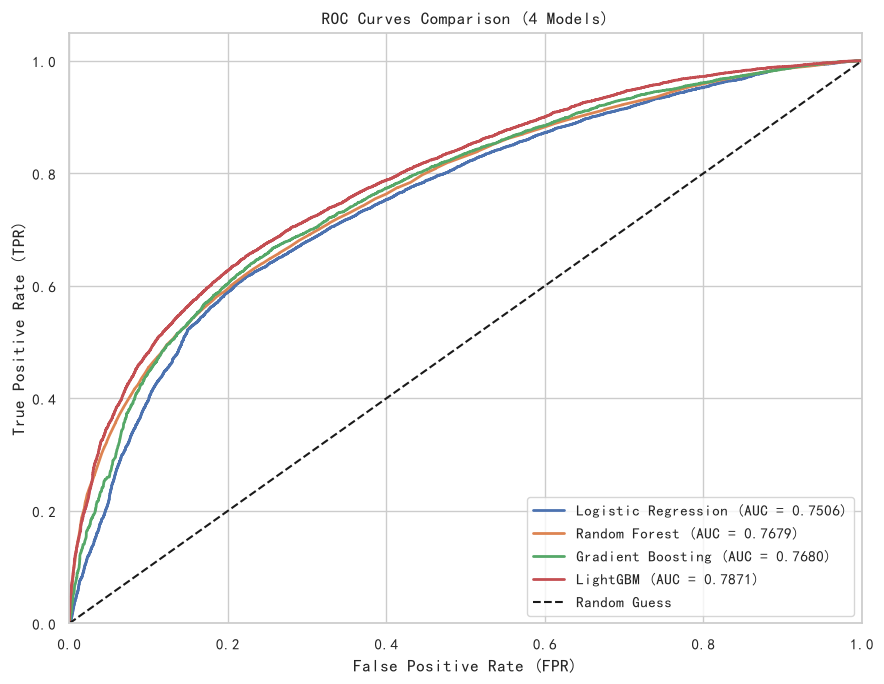

In [13]:
# =====================================================================
# 4 & 5. 模型训练与综合对比评估（含 LightGBM 四模型横向对比版）
# =====================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier # 导入已安装的 LightGBM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

# ---------------------------------------------------------------------
# 4.0 终极列对齐与 NaN 强行填补（确保逻辑回归绝对不报错）
# ---------------------------------------------------------------------
# 1. 确保训练集和测试集的特征列完全一致
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 2. 强行将特征矩阵中由于任何原因残留下来的 NaN 全部填补为 0
X_train_clean = X_train.fillna(0)
X_test_clean = X_test.fillna(0)

# 3. 确保所有数据类型都是数值型，防止 bool 类型导致标准化报错
X_train_clean = X_train_clean.astype(float)
X_test_clean = X_test_clean.astype(float)

# ---------------------------------------------------------------------
# 4.1 特征标准化
# ---------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# ---------------------------------------------------------------------
# 4.2 初始化 4 个模型进行横向对比
# ---------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1, verbose=-1)
}

# 用于存储最终评估结果的字典
results = {}
curves = {}

# ---------------------------------------------------------------------
# 4.3 循环训练与测试
# ---------------------------------------------------------------------
print("开始 4 个模型的训练与评估...\n")

for name, model in models.items():
    start_time = time.time()
    
    # 训练模型
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    
    # 在测试集上进行预测
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # 获取预测为 1 (No-Show) 的概率
    
    # 计算评估指标
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    
    # 保存指标结果
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc_score,
        "Train Time (s)": train_time
    }
    
    # 保存 ROC 曲线数据
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    curves[name] = (fpr, tpr, auc_score)
    
    print(f"[{name}] 训练完成！用时: {train_time:.2f} 秒")

print("\n模型训练全部结束！\n")

# ---------------------------------------------------------------------
# 5.1 展现量化对比表格
# ---------------------------------------------------------------------
df_perf = pd.DataFrame(results).T
print("=== 模型性能横向对比表 ===")
print(df_perf.round(4))

# ---------------------------------------------------------------------
# 5.2 绘制 ROC 曲线进行可视化对比
# ---------------------------------------------------------------------
plt.figure(figsize=(9, 7))
for name, (fpr, tpr, auc_score) in curves.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves Comparison (4 Models)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()